Temat projektu: Analiza wybranych danych pochodzących z rozgrywek gry Leauge of Legends.

Wczytaliśmy poniższe biblioteki w celu:
1. numpy - do obliczania danych statystycznych i konwersji danych na listy.
2. pandas - do otwierania pliku o rozszerzeniu .csv.
3. scipy.stats - do obliczania kurtozy i skośności.
4. matplotlib.pyplot - do wizualizacji wyników.

In [127]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

Poniżej znajduje się sekcja odpowiedzialna za wczytanie pliku z naszą bazą danych. W tej sekcji znajdują się również wybrane przez nas cechy takie jak:
    gameDuration - czas trwania gry (zmienna ciągła). 
    winner - zwycięska drużyna (zmienna kategoryczna: 1 lub 2). 
    t1_towerKills i t2_towerKills - ilość zburzonych przez daną drużyne wież (maksymalnie 11 na grę) (zmienna ciągła).
    firstDragon - która drużyna jako pierwsza zabiła smoka (smok jest ważnym celem gry i jego zabicie daje drużynie przewagę) (zmienna kategoryczna: 1 lub 2).

In [128]:
file_path = "C:\Moje Doc\Desktop\Projekt biostat\Dataset\games.csv"
data = pd.read_csv(file_path)

cechy = ['gameDuration', 'winner', 't1_towerKills', 't2_towerKills','firstDragon']
data = data[cechy]


Funkcja statistics przyjmuje argument data i zwraca nam wartości statystyczne takie jak:
1. Średnia (mean): Suma wszystkich wartości podzielona przez ich liczbę. Przedstawia przeciętną wartość zbioru danych.
2. Mediana (median): Środkowa wartość uporządkowanego zbioru danych. Wartość dzieląca zbiór na dwie równe części.
3. Wariancja (variance): Miara rozrzutu danych wokół średniej.
4. Odchylenie standardowe (standard deviation): Pierwiastek kwadratowy z wariancji. Przedstawia przeciętną odległość wartości danych od średniej.
5. Zakres (range): Różnica między największą a najmniejszą wartością w zbiorze danych.
6. Pierwszy kwartyl (Q1): Wartość, poniżej której znajduje się 25% danych.
7. Trzeci kwartyl (Q3): Wartość, poniżej której znajduje się 75% danych.
8. Rozstęp międzykwartylowy (IQR): Różnica między trzecim a pierwszym kwartylem. Przedstawia rozrzut środkowych 50% danych.
9. Skośność (skewness): Miara asymetrii rozkładu danych. Dodatnia skośność oznacza, że ogon rozkładu jest dłuższy po prawej stronie, a ujemna, że po lewej.
10. Kurtoza (kurtosis): Wysoka kurtoza wskazuje na wiele wartości w pobliżu średniej i długie ogony, niska kurtoza oznacza bardziej płaski rozkład.

In [129]:
#Obliczenia stastystyczne
def statistics(data):
    Średnia=round(np.mean(data),2)
    Mediana=round(np.median(data),2)
    Wariancja=round(np.var(data, ddof=1),2)
    Odchylenie_standardowe=round(np.std(data, ddof=1),2)
    Zakres=round(np.ptp(data),2)
    Q1=round(np.percentile(data, 25),2)
    Q3=round(np.percentile(data, 75),2)
    IQR=round(np.percentile(data, 75) - np.percentile(data, 25),2)
    Skosnosc = round(stats.skew(data),2)
    Kurtoza = round(stats.kurtosis(data),2)
    return Średnia, Mediana, Wariancja, Odchylenie_standardowe, Zakres, Q1, Q3, IQR, Skosnosc, Kurtoza

Poniżej znajdują się wszystkie funkcje do wizualizacji naszych danych: histogramy, boxploty i wykresy kołowe.

In [130]:
#Funkcje do wyswietlania statystyk i wykresów
def histogram(title, dane, srednia, mediana, OX, xlim):
    hist_output = plt.hist(dane, bins=11, color='#d1ebd5', edgecolor='black')
    counts, bins = hist_output[0], hist_output[1]
    bin_centers = 0.5 * (bins[1:] + bins[:-1])

    plt.plot(bin_centers, counts, color='darkorange', marker='o', linewidth=2, label="Frequency Polygon")
    plt.axvline(mean_gameDuration, color='green', linestyle='--', linewidth=2, label=f'Mean: {srednia:.2f}')
    plt.axvline(median_gameDuration, color='red', linestyle=':', linewidth=2, label=f'Median: {mediana:.2f}')
    plt.title(f'Histogram - {title}', size=15)
    plt.xlabel(OX)
    plt.xlim(0, xlim)
    plt.ylabel('Częstotliwość')
    plt.legend(loc='upper right')
    plt.grid()

In [131]:
def boxplot(title ,dane, OX):
    plt.boxplot(dane, patch_artist=True, boxprops=dict(facecolor="#d1ebd5", color="black"))
    plt.title(f'Boxplot - Czas trwania gry\n{title}', size=15)
    plt.ylabel(OX)
    plt.grid(axis='y', linestyle='--', alpha=0.7)


In [132]:
colors = ['skyblue', 'indianred']
labels = ['Team 1', 'Team 2']
def pie(dane, title):
    total=len(dane)
    
    count1=(dane == 1).sum() #Liczba wystąpień 1
    count2=(dane == 2).sum() #Liczba wystąpień 2
    percent1=(count1 / total) * 100
    percent2=(count2 / total) * 100
    
    sizes=[percent1, percent2]
    
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}, textprops={'fontsize': 15},)
    plt.title(f'Wykres kołowy - {title}\n', size=15)
    plt.axis('equal')

Funkcja do wyświetlania statystyk dla danego zbioru danych.

In [133]:
def staty(title, data):
    nazwa_statystyk = ['Średnia', 'Mediana', 'Wariancja', 'Odchylenie_standardowe', 'Zakres', 'Q1', 'Q3', 'IQR', 'Skosnosć', 'Kurtoza']
    mean, median, wariancja, odchylenie_standardowe, zakres, Q1, Q3, IQR, skosnosc, kurtoza = statistics(data)
    wyniki = [mean, median, wariancja, odchylenie_standardowe, zakres, Q1, Q3, IQR, skosnosc, kurtoza]
    print(f"Dane statystyczne: {title}")
    for nazwa, wynik in zip(nazwa_statystyk, wyniki):
        print(f" {nazwa}: {wynik}")
    print()

Analiza, obliczanie i wizualiacja poszczególnych danych.

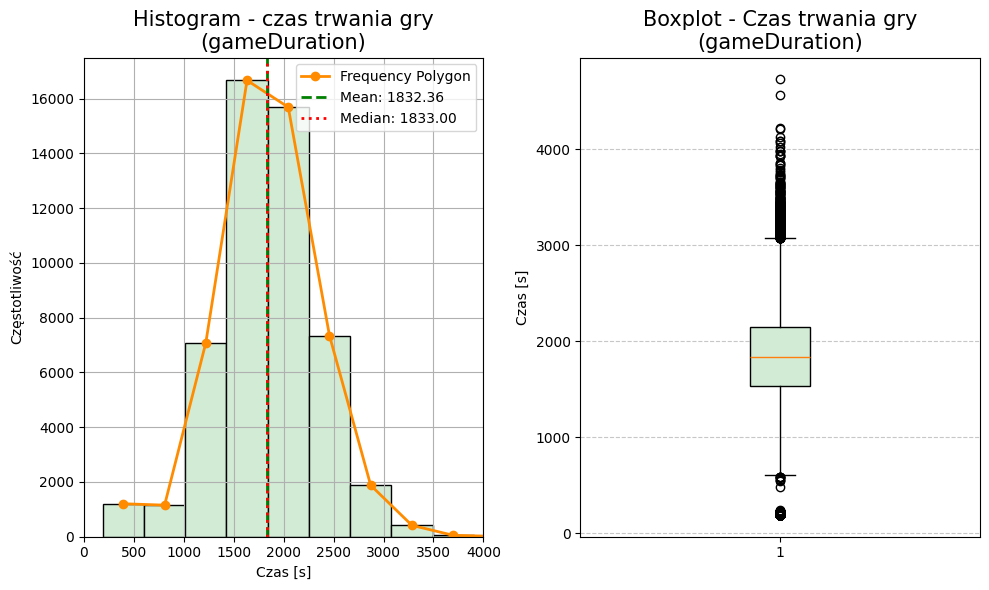

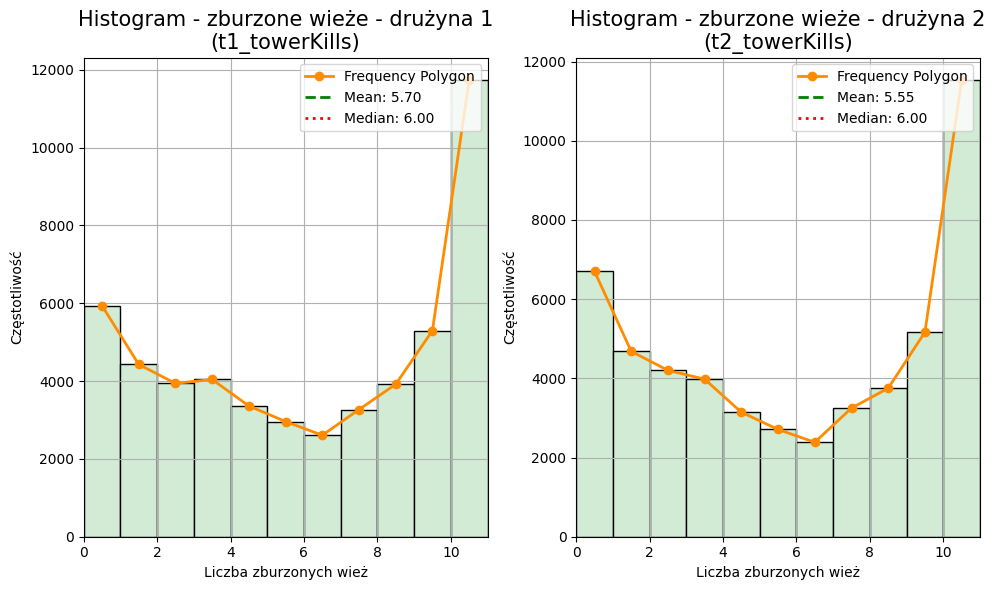

Dane statystyczne: Czas trwania gry
 Średnia: 1832.36
 Mediana: 1833.0
 Wariancja: 262162.12
 Odchylenie_standardowe: 512.02
 Zakres: 4538
 Q1: 1531.0
 Q3: 2148.0
 IQR: 617.0
 Skosnosć: -0.31
 Kurtoza: 1.49

Dane statystyczne: Zburzone wieże - drużyna 1
 Średnia: 5.7
 Mediana: 6.0
 Wariancja: 14.44
 Odchylenie_standardowe: 3.8
 Zakres: 11
 Q1: 2.0
 Q3: 9.0
 IQR: 7.0
 Skosnosć: -0.09
 Kurtoza: -1.43

Dane statystyczne: Zburzone wieże - drużyna 2
 Średnia: 5.55
 Mediana: 6.0
 Wariancja: 14.91
 Odchylenie_standardowe: 3.86
 Zakres: 11
 Q1: 2.0
 Q3: 9.0
 IQR: 7.0
 Skosnosć: -0.04
 Kurtoza: -1.47



In [134]:
#DANE CIĄGŁE

#gameDuration
mean_gameDuration, median_gameDuration, *other_stats = statistics(data["gameDuration"])
gameDuration=data["gameDuration"]

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
histogram('czas trwania gry\n(gameDuration)' ,gameDuration, mean_gameDuration, median_gameDuration, 'Czas [s]', 4000)

plt.subplot(1, 2, 2)
boxplot('(gameDuration)', gameDuration, "Czas [s]")

plt.tight_layout()
plt.show()

#t1_towerKills i t2_towerKills
mean_t1_towerKills, median_t1_towerKills, *other_stats = statistics(data["t1_towerKills"])
mean_t2_towerKills, median_t2_towerKills, *other_stats = statistics(data["t2_towerKills"])
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
histogram('zburzone wieże - drużyna 1\n(t1_towerKills)', data['t1_towerKills'], mean_t1_towerKills, median_t1_towerKills, 'Liczba zburzonych wież', 11)

plt.subplot(1, 2, 2)
histogram('zburzone wieże - drużyna 2\n(t2_towerKills)', data['t2_towerKills'], mean_t2_towerKills, median_t2_towerKills, 'Liczba zburzonych wież', 11)

plt.tight_layout()
plt.show()

staty('Czas trwania gry' ,data['gameDuration'])
staty('Zburzone wieże - drużyna 1' ,data['t1_towerKills'])
staty('Zburzone wieże - drużyna 2' ,data['t2_towerKills'])

C:\Users\Win10_1\AppData\Local\Temp\ipykernel_16976\1627718109.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(


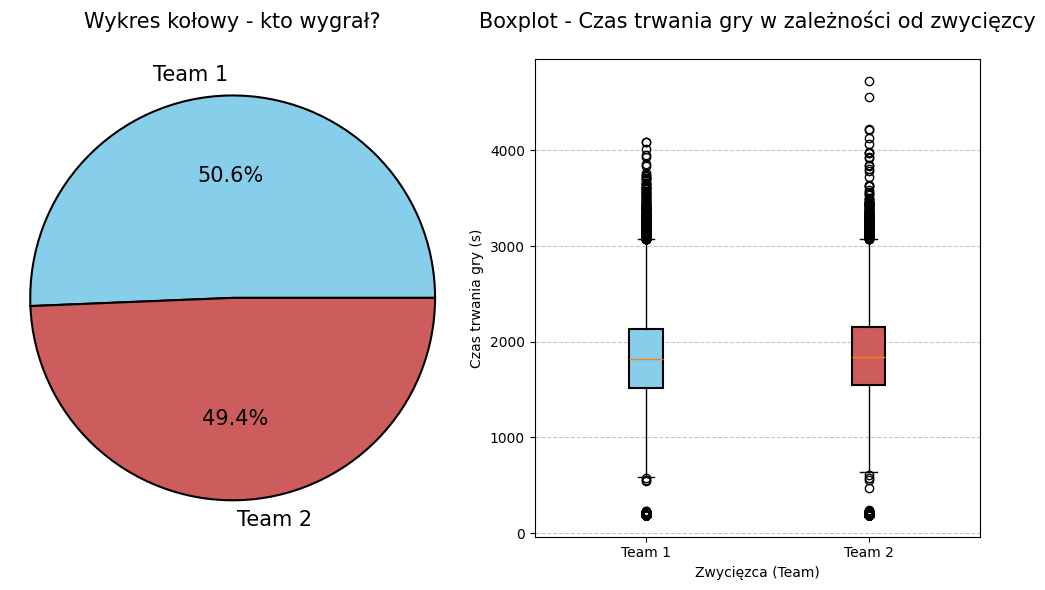

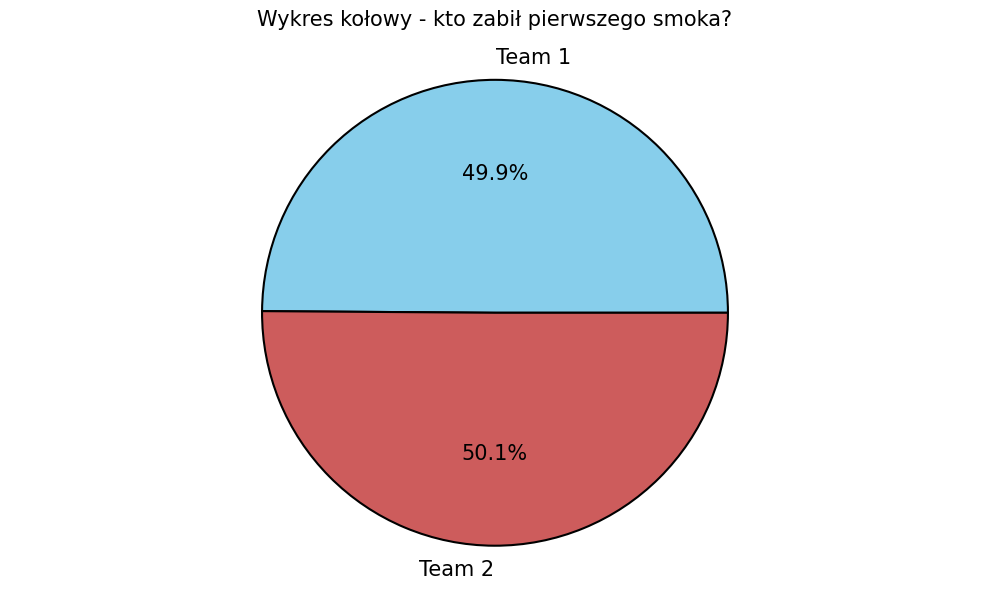

In [135]:
#Dane kategoryczne

#Winner
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
pie(data['winner'], 'kto wygrał?')


#Zad 2.c.iii - 2 boxploty
categories = data['winner'].unique()  # Unikalne wartości kategorii (1, 2)
box_data = [data[data['winner'] == cat]['gameDuration'] for cat in categories]

plt.subplot(1, 2, 2)
boxplot = plt.boxplot(
    box_data,
    labels=[f"Team {int(cat)}" for cat in categories], 
    patch_artist=True,
    boxprops=dict(facecolor="#d1ebd5", color="black", linewidth=1.5)
)
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Boxplot - Czas trwania gry w zależności od zwycięzcy\n', size=15)
plt.xlabel('Zwycięzca (Team)')
plt.ylabel('Czas trwania gry (s)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


#firstDragon
plt.figure(figsize=(10, 6))
pie(data['firstDragon'], 'kto zabił pierwszego smoka?')

plt.tight_layout()
plt.show()

Z wykresów kołowych możemy wywnioskować, że dane rozkładały się praktycznie po równo dla każdej z drużyn z minimalną przewagą drużyny 1 w przypadku zwycięstw i z minimalną przewagą drużyny 2  przypadku zabicia pierwszego smoka.
Z wykresów pudełkowych możemy odczytać, że jak drużyna czerwona wygryała to ich gra trwała dłużej.

Dla wybranych zmiennych 'gameDuration' i 't1_towerKills' dokonaliśmy analizy korelacyjnej wraz z analizą regresji liniowej wyznaczając prostą regresji.


Analiza dla zmiennych: gameDuration i t1_towerKills
 Współczynnik korelacji (Pearson): 0.3695
 Równanie regresji: y = 0.0027x + 0.6750


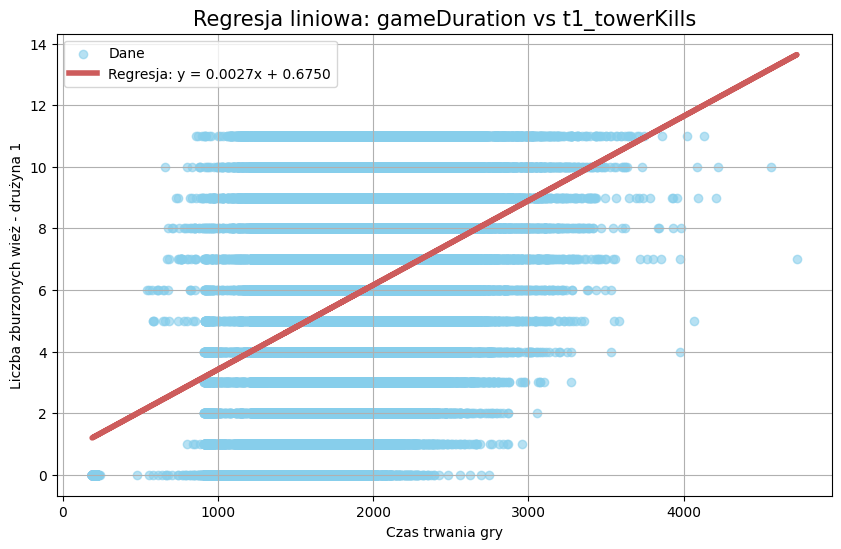

In [136]:
#Zadanie 3
variable_pairs = [('gameDuration', 't1_towerKills')]

for x_wariancja, y_wariancja in variable_pairs:
    print(f"\nAnaliza dla zmiennych: {x_wariancja} i {y_wariancja}")

    # Dane
    x = data[x_wariancja].to_numpy()
    y = data[y_wariancja].to_numpy()

    # obliczanie korelacji
    correlation = np.corrcoef(x, y)[0, 1]
    print(f" Współczynnik korelacji (Pearson): {correlation:.4f}")

    # Regresja liniowa
    A = np.vstack([x, np.ones(len(x))]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    print(f" Równanie regresji: y = {a:.4f}x + {b:.4f}")

    # wykres
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color='skyblue', alpha=0.6, label='Dane')
    plt.plot(x, a * x + b, color='indianred', linewidth=4, label=f'Regresja: y = {a:.4f}x + {b:.4f}')
    plt.title(f"Regresja liniowa: {x_wariancja} vs {y_wariancja}", size=15)
    plt.xlabel('Czas trwania gry')
    plt.ylabel('Liczba zburzonych wież - drużyna 1')
    plt.legend()
    plt.grid()
    plt.show()
        

Z odczytanego współczynnika korelacji możemy stierdzić że zmienne 'gameDuration' i 't1_towerKills' są od siebie zależne, ale w małym stopniu.